In [11]:
# Cell 1: fully remove the stale packages Colab preinstalled
!pip uninstall -y kaggle kagglesdk -q

In [1]:
# Cell 2: fresh install
!pip install -q kagglesdk kaggle
!kaggle --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 4.8 MB/s eta 0:00:00
Kaggle CLI 2.2.3


In [4]:
from google.colab import files
files.upload()  # select kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c home-credit-default-risk -p /content
!unzip -q /content/home-credit-default-risk.zip -d /content

Saving kaggle.json to kaggle (1).json
100% 688M/688M [00:05<00:00, 122MB/s]



Step 1 done. App-level shape: (50000, 27)
Step 2 done. Bureau aggregation shape: (42786, 10)
Step 3 done. Previous application aggregation shape: (47320, 8)
Step 4 done. Installments: (47414, 5), POS: (47066, 4), CC: (14118, 4)
Step 5 done. Final feature count: 51
default.payment.next.month
0    0.91954
1    0.08046
Name: proportion, dtype: float64
Step 6 done. Baseline ROC-AUC (full feature set): 0.721
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Step 7 done. Best CV ROC-AUC: 0.735
Best params: {'clf__colsample_bytree': 0.5, 'clf__gamma': 0.3, 'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__min_child_weight': 3}
Final Cross-Validated ROC-AUC: 0.733
Holdout Test ROC-AUC: 0.732
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      9195
           1       0.33      0.08      0.13       805

    accuracy                           0.91     10000
   macro avg       0.63      0.53      0.54     10000
weighted avg       

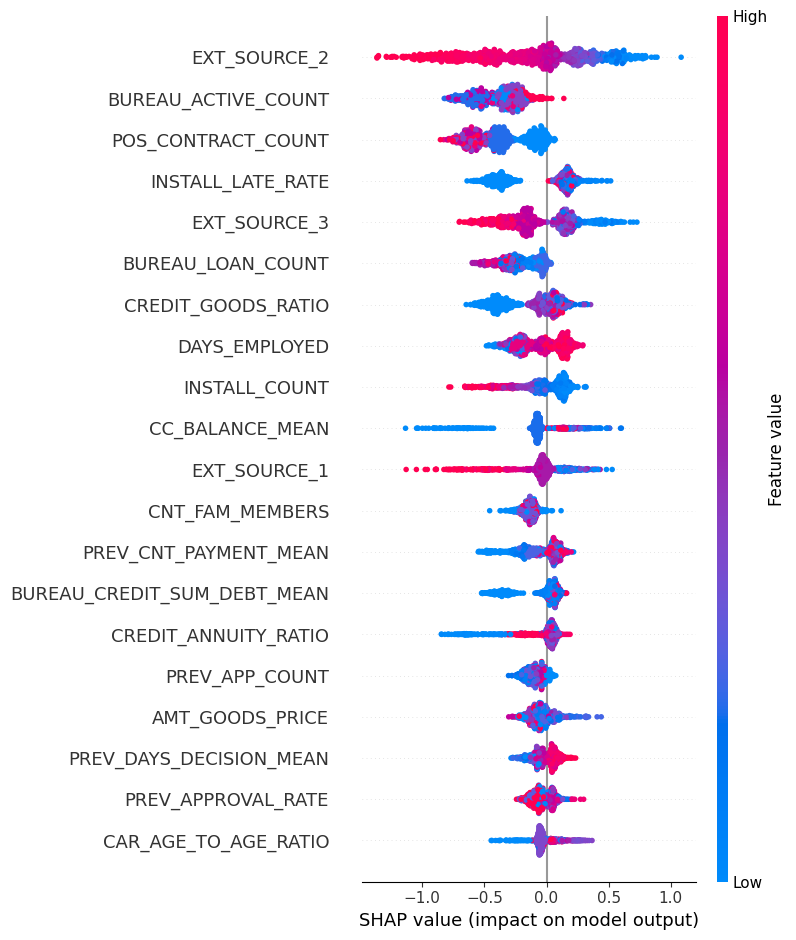

In [5]:

# STEP 1: Load application data, engineer 12 risk ratios + EXT_SOURCE

import pandas as pd
import numpy as np

DATA_DIR = '/content'  # change to '/kaggle/input/home-credit-default-risk' if on Kaggle

raw_df = pd.read_csv(f'{DATA_DIR}/application_train.csv')
credit_df = raw_df.sample(n=50000, random_state=42).reset_index(drop=True)
credit_df.rename(columns={'TARGET': 'default.payment.next.month'}, inplace=True)
credit_df['DAYS_EMPLOYED'] = credit_df['DAYS_EMPLOYED'].replace(365243, np.nan)

eps = 1e-6
ratio_features = {
    'CREDIT_INCOME_RATIO':      credit_df['AMT_CREDIT'] / (credit_df['AMT_INCOME_TOTAL'] + eps),
    'ANNUITY_INCOME_RATIO':     credit_df['AMT_ANNUITY'] / (credit_df['AMT_INCOME_TOTAL'] + eps),
    'CREDIT_ANNUITY_RATIO':     credit_df['AMT_CREDIT'] / (credit_df['AMT_ANNUITY'] + eps),
    'CREDIT_GOODS_RATIO':       credit_df['AMT_CREDIT'] / (credit_df['AMT_GOODS_PRICE'] + eps),
    'INCOME_PER_FAM_MEMBER':    credit_df['AMT_INCOME_TOTAL'] / (credit_df['CNT_FAM_MEMBERS'] + eps),
    'CHILDREN_RATIO':           credit_df['CNT_CHILDREN'] / (credit_df['CNT_FAM_MEMBERS'] + eps),
    'INCOME_PER_REGION_RATING': credit_df['AMT_INCOME_TOTAL'] / (credit_df['REGION_RATING_CLIENT'] + eps),
    'EMPLOYED_TO_AGE_RATIO':    credit_df['DAYS_EMPLOYED'] / (credit_df['DAYS_BIRTH'] + eps),
    'REGISTRATION_TO_AGE':      credit_df['DAYS_REGISTRATION'] / (credit_df['DAYS_BIRTH'] + eps),
    'ID_PUBLISH_TO_AGE':        credit_df['DAYS_ID_PUBLISH'] / (credit_df['DAYS_BIRTH'] + eps),
    'CAR_AGE_TO_AGE_RATIO':     credit_df['OWN_CAR_AGE'] / (-credit_df['DAYS_BIRTH'] / 365 + eps),
    'ANNUITY_TO_AGE_RATIO':     credit_df['AMT_ANNUITY'] / (-credit_df['DAYS_BIRTH'] + eps),
}
credit_df = pd.concat([credit_df, pd.DataFrame(ratio_features)], axis=1)

base_cols = ['SK_ID_CURR', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
             'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
             'REGION_RATING_CLIENT_W_CITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
             'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
ratio_cols = list(ratio_features.keys())

credit_df = credit_df[['default.payment.next.month'] + base_cols + ratio_cols]
print(f"Step 1 done. App-level shape: {credit_df.shape}")
sample_ids = credit_df['SK_ID_CURR']  # used to filter the huge supplementary tables below



# STEP 2: Aggregate bureau.csv + bureau_balance.csv (credit bureau history)

bureau = pd.read_csv(f'{DATA_DIR}/bureau.csv')
bureau = bureau[bureau['SK_ID_CURR'].isin(sample_ids)]

# bureau_balance.csv: monthly status per bureau loan -> delinquency rate per loan
bureau_balance = pd.read_csv(f'{DATA_DIR}/bureau_balance.csv')
bureau_balance = bureau_balance[bureau_balance['SK_ID_BUREAU'].isin(bureau['SK_ID_BUREAU'])]
bureau_balance['IS_DPD'] = bureau_balance['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)
bb_agg = bureau_balance.groupby('SK_ID_BUREAU').agg(
    BB_MONTHS_COUNT=('MONTHS_BALANCE', 'count'),
    BB_DPD_RATE=('IS_DPD', 'mean')
).reset_index()
bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')

bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_CREDIT_OVERDUE_MEAN=('AMT_CREDIT_SUM_OVERDUE', 'mean'),
    BUREAU_CREDIT_SUM_MEAN=('AMT_CREDIT_SUM', 'mean'),
    BUREAU_CREDIT_SUM_DEBT_MEAN=('AMT_CREDIT_SUM_DEBT', 'mean'),
    BUREAU_DAY_OVERDUE_MAX=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_BB_DPD_RATE_MEAN=('BB_DPD_RATE', 'mean'),
).reset_index()
bureau_agg['BUREAU_DEBT_CREDIT_RATIO'] = (
    bureau_agg['BUREAU_CREDIT_SUM_DEBT_MEAN'] / (bureau_agg['BUREAU_CREDIT_SUM_MEAN'] + eps)
)
print(f"Step 2 done. Bureau aggregation shape: {bureau_agg.shape}")



# STEP 3: Aggregate previous_application.csv (prior Home Credit loan history)

prev = pd.read_csv(f'{DATA_DIR}/previous_application.csv')
prev = prev[prev['SK_ID_CURR'].isin(sample_ids)]
prev['IS_APPROVED'] = (prev['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)
prev['IS_REFUSED'] = (prev['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)

prev_agg = prev.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT=('SK_ID_PREV', 'count'),
    PREV_APPROVAL_RATE=('IS_APPROVED', 'mean'),
    PREV_REFUSAL_RATE=('IS_REFUSED', 'mean'),
    PREV_AMT_APPLICATION_MEAN=('AMT_APPLICATION', 'mean'),
    PREV_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
    PREV_DAYS_DECISION_MEAN=('DAYS_DECISION', 'mean'),
    PREV_CNT_PAYMENT_MEAN=('CNT_PAYMENT', 'mean'),
).reset_index()
print(f"Step 3 done. Previous application aggregation shape: {prev_agg.shape}")


# STEP 4: Aggregate installments_payments.csv, POS_CASH_balance.csv,
#         credit_card_balance.csv (repayment behavior history)

installments = pd.read_csv(f'{DATA_DIR}/installments_payments.csv')
installments = installments[installments['SK_ID_CURR'].isin(sample_ids)]
installments['DAYS_LATE'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
installments['PAYMENT_RATIO'] = installments['AMT_PAYMENT'] / (installments['AMT_INSTALMENT'] + eps)
installments['IS_LATE'] = (installments['DAYS_LATE'] > 0).astype(int)
install_agg = installments.groupby('SK_ID_CURR').agg(
    INSTALL_LATE_RATE=('IS_LATE', 'mean'),
    INSTALL_DAYS_LATE_MEAN=('DAYS_LATE', 'mean'),
    INSTALL_PAYMENT_RATIO_MEAN=('PAYMENT_RATIO', 'mean'),
    INSTALL_COUNT=('NUM_INSTALMENT_NUMBER', 'count'),
).reset_index()

pos = pd.read_csv(f'{DATA_DIR}/POS_CASH_balance.csv')
pos = pos[pos['SK_ID_CURR'].isin(sample_ids)]
pos_agg = pos.groupby('SK_ID_CURR').agg(
    POS_SK_DPD_MEAN=('SK_DPD', 'mean'),
    POS_SK_DPD_DEF_MEAN=('SK_DPD_DEF', 'mean'),
    POS_CONTRACT_COUNT=('SK_ID_PREV', 'nunique'),
).reset_index()

cc = pd.read_csv(f'{DATA_DIR}/credit_card_balance.csv')
cc = cc[cc['SK_ID_CURR'].isin(sample_ids)]
cc['UTILIZATION'] = cc['AMT_BALANCE'] / (cc['AMT_CREDIT_LIMIT_ACTUAL'] + eps)
cc_agg = cc.groupby('SK_ID_CURR').agg(
    CC_BALANCE_MEAN=('AMT_BALANCE', 'mean'),
    CC_UTILIZATION_MEAN=('UTILIZATION', 'mean'),
    CC_SK_DPD_MEAN=('SK_DPD', 'mean'),
).reset_index()
print(f"Step 4 done. Installments: {install_agg.shape}, POS: {pos_agg.shape}, CC: {cc_agg.shape}")


# STEP 5: Merge everything, clean, split

from sklearn.model_selection import train_test_split

final_df = (credit_df
            .merge(bureau_agg, on='SK_ID_CURR', how='left')
            .merge(prev_agg, on='SK_ID_CURR', how='left')
            .merge(install_agg, on='SK_ID_CURR', how='left')
            .merge(pos_agg, on='SK_ID_CURR', how='left')
            .merge(cc_agg, on='SK_ID_CURR', how='left'))

final_df = final_df.replace([np.inf, -np.inf], np.nan)
final_df = final_df.drop(columns=['SK_ID_CURR'])
final_df = final_df.fillna(final_df.median(numeric_only=True))

X = final_df.drop(columns=['default.payment.next.month'])
y = final_df['default.payment.next.month']
print(f"Step 5 done. Final feature count: {X.shape[1]}")
print(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# STEP 6: Baseline — leak-free (scaler + SMOTE refit inside each CV fold)

import xgboost
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', xgboost.XGBClassifier(random_state=42, eval_metric='logloss'))
])

baseline_score = cross_val_score(pipe, X_train, y_train, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
print(f"Step 6 done. Baseline ROC-AUC (full feature set): {baseline_score.mean():.3f}")



# STEP 7: Grid search over the full pipeline

from sklearn.model_selection import GridSearchCV

params = {
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__max_depth': [3, 5, 7],
    'clf__min_child_weight': [3, 7],
    'clf__gamma': [0.1, 0.3],
    'clf__colsample_bytree': [0.5, 0.8],
}
grid_search = GridSearchCV(pipe, param_grid=params, scoring='roc_auc', cv=cv_strategy, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print(f"Step 7 done. Best CV ROC-AUC: {grid_search.best_score_:.3f}")
print(f"Best params: {grid_search.best_params_}")


# STEP 8: Final metrics + SHAP on the true holdout set

from sklearn.metrics import roc_auc_score, classification_report
import shap

best_pipe = grid_search.best_estimator_
final_cv_scores = cross_val_score(best_pipe, X_train, y_train, cv=10, scoring='roc_auc', n_jobs=-1)
print(f"Final Cross-Validated ROC-AUC: {final_cv_scores.mean():.3f}")

y_test_proba = best_pipe.predict_proba(X_test)[:, 1]
print(f"Holdout Test ROC-AUC: {roc_auc_score(y_test, y_test_proba):.3f}")
print(classification_report(y_test, best_pipe.predict(X_test)))

scaler = best_pipe.named_steps['scaler']
xgb_model = best_pipe.named_steps['clf']
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

explainer = shap.TreeExplainer(xgb_model)
sample = X_test_scaled.sample(n=min(1000, len(X_test_scaled)), random_state=42)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample)